# ETL - Extract, Transform, Load

### Extract Data

In [277]:
import pandas as pd

url_1k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/1k.csv"
url_2k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/2k.csv"
url_4k7 = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/4k7.csv"

# 1000 Ω load
data_1k_load = pd.read_csv(url_1k, skiprows=17, usecols=[0, 1, 2])
data_1k_load.columns = ["time", "dac", "shunt"]

# 2000 Ω load
data_2k_load = pd.read_csv(url_2k, skiprows=17, usecols=[0, 1, 2])
data_2k_load.columns = ["time", "dac", "shunt"]

# 4700 Ω load
data_4k7_load = pd.read_csv(url_4k7, skiprows=17, usecols=[0, 1, 2])
data_4k7_load.columns = ["time", "dac", "shunt"]

<Axes: xlabel='time'>

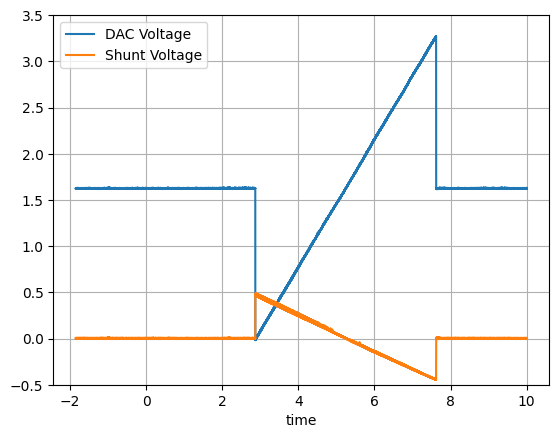

In [278]:
data_1k_load.rename(columns={"dac": "DAC Voltage", "shunt": "Shunt Voltage"}).plot(
    x="time", y=["DAC Voltage", "Shunt Voltage"], grid=True, ylim=(-0.5, 3.5)
)

In [ ]:
def extract_ramp_region(df, column, trigger_threshold):

    data = df.copy()

    diff = data[column].diff().abs()

    transition_points = diff[diff > trigger_threshold].index

    start = transition_points[0] + 2
    end = transition_points[-1] - 2

    return data.loc[start:end].copy()

In [ ]:
# Detecta região de rampa a partir de variação abrupta no DAC (indicando início e fim da rampa)
# Faz apenas no DAC pois o importante é descobrir o index de início e fim da rampa.
# Utiliza-se os mesmos indexes obtidos para manter em fase com o sinal do shunt.

data_1k_load = extract_ramp_region(data_1k_load, column="dac", trigger_threshold=0.5)
data_2k_load = extract_ramp_region(data_2k_load, column="dac", trigger_threshold=0.5)
data_4k7_load = extract_ramp_region(data_4k7_load, column="dac", trigger_threshold=0.5)

### Transform Data

<Axes: title={'center': 'Current [mA]'}, xlabel='time'>

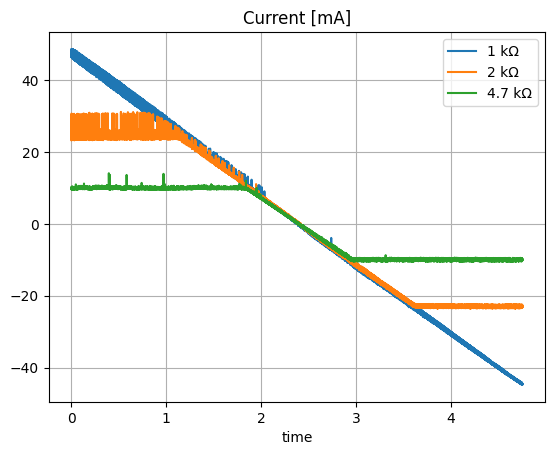

In [281]:
shunt_resistance = 10  # Ω

data_1k_load["current"] = (data_1k_load["shunt"] / shunt_resistance) * 1000
data_2k_load["current"] = (data_2k_load["shunt"] / shunt_resistance) * 1000
data_4k7_load["current"] = (data_4k7_load["shunt"] / shunt_resistance) * 1000

data_1k_load["time"] = data_1k_load["time"] - data_1k_load["time"].iloc[0]
data_2k_load["time"] = data_2k_load["time"] - data_2k_load["time"].iloc[0]
data_4k7_load["time"] = data_4k7_load["time"] - data_4k7_load["time"].iloc[0]

ax = data_1k_load.plot(
    x="time", y="current", grid=True, title="Current [mA]", label="1 kΩ"
)

data_2k_load.plot(x="time", y="current", ax=ax, label="2 kΩ", grid=True)

data_4k7_load.plot(x="time", y="current", ax=ax, label="4.7 kΩ", grid=True)

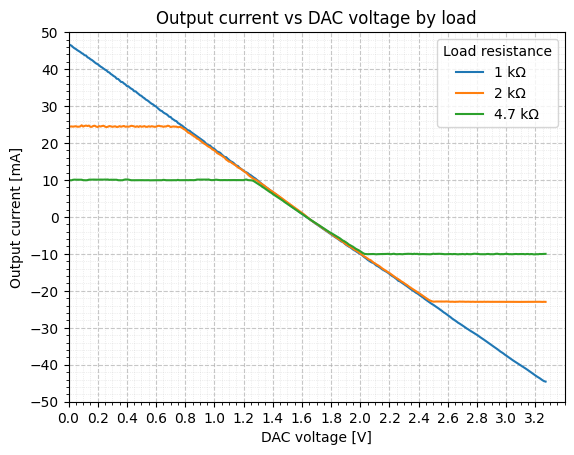

In [287]:
dac_step = 0.01

load_1k_cmp = data_1k_load.copy()
load_2k_cmp = data_2k_load.copy()
load_4k7_cmp = data_4k7_load.copy()

load_1k_cmp["load"] = "1 kΩ"
load_2k_cmp["load"] = "2 kΩ"
load_4k7_cmp["load"] = "4.7 kΩ"

all_data = pd.concat([load_1k_cmp, load_2k_cmp, load_4k7_cmp], ignore_index=True)

all_data["dac_bin"] = (all_data["dac"] // dac_step) * dac_step

comparison = all_data.pivot_table(
    index="dac_bin", columns="load", values="current", aggfunc="mean"
)

# =========================================================
# Plot
# =========================================================

ax = comparison.plot()

# =========================================================
# X axis
# =========================================================

ax.set_xlim(0, 3.4)

ax.set_xticks([i / 10 for i in range(0, 34, 2)])

# =========================================================
# Y axis
# =========================================================

ax.set_ylim(-50, 50)

ax.set_yticks(range(-50, 51, 10))

# =========================================================
# Grid
# =========================================================

ax.grid(True, which="major", linestyle="--", alpha=0.7)

# Optional minor grid
ax.minorticks_on()

ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.4)

# =========================================================
# Labels and title
# =========================================================

ax.set_xlabel("DAC voltage [V]")

ax.set_ylabel("Output current [mA]")

ax.set_title("Output current vs DAC voltage by load")

# =========================================================
# Legend
# =========================================================

ax.legend(title="Load resistance")

# EDA - Exploratory Data Analysis



In [283]:
comparison["max_current"] = comparison[["1 kΩ", "2 kΩ", "4.7 kΩ"]].max(axis=1)
comparison["min_current"] = comparison[["1 kΩ", "2 kΩ", "4.7 kΩ"]].min(axis=1)

comparison["current_spread"] = comparison["max_current"] - comparison["min_current"]

comparison[["1 kΩ", "2 kΩ", "4.7 kΩ", "current_spread"]].head()

load,1 kΩ,2 kΩ,4.7 kΩ,current_spread
dac_bin,,,,
-0.03,NaN,24.277455,9.840365,14.437091
-0.02,46.937600,24.329558,9.917024,37.020576
-0.01,47.130724,24.466085,9.919587,37.211137
0.00,46.845262,24.658353,9.930252,36.915010
0.01,46.523013,24.434646,9.930973,36.592040


In [284]:
comparison["current_spread"].describe()

count    331.000000
mean      14.369634
std       11.803608
min        0.049576
25%        1.822758
50%       13.351757
75%       24.703259
max       37.211137
Name: current_spread, dtype: float64

<Axes: title={'center': 'Current spread between loads'}, xlabel='dac_bin'>

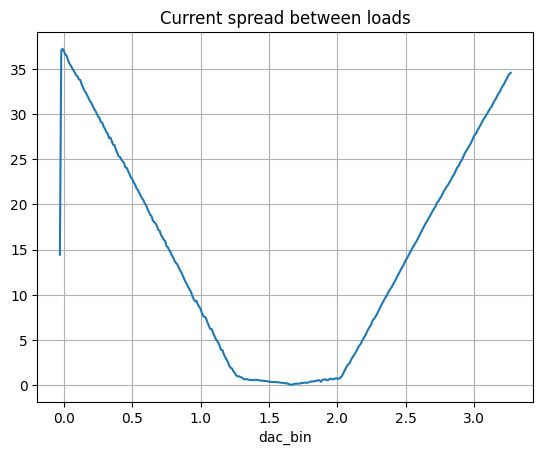

In [285]:
comparison["current_spread"].plot(grid=True, title="Current spread between loads")

In [286]:
data_1k_load["current"].describe()

count    59406.000000
mean         0.790920
std         26.656282
min        -44.846875
25%        -22.371875
50%          0.320312
75%         23.834766
max         48.792187
Name: current, dtype: float64